
Model: LOGREG_SMOTE
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     56864
       Fraud       0.06      0.91      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.98      0.99     56962

AUC-ROC : 0.9711
AUC-PR  : 0.7270  ← most important for imbalanced data

Model: LOGREG_UNDER
              precision    recall  f1-score   support

       Legit       1.00      0.96      0.98     56864
       Fraud       0.04      0.92      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962

AUC-ROC : 0.9771
AUC-PR  : 0.6922  ← most important for imbalanced data

Model: XGBOOST_SMOTE
              precision    recall  f1-score   support

       Legit       1.00      0.99      1.00     56864
       Fraud       0.17      

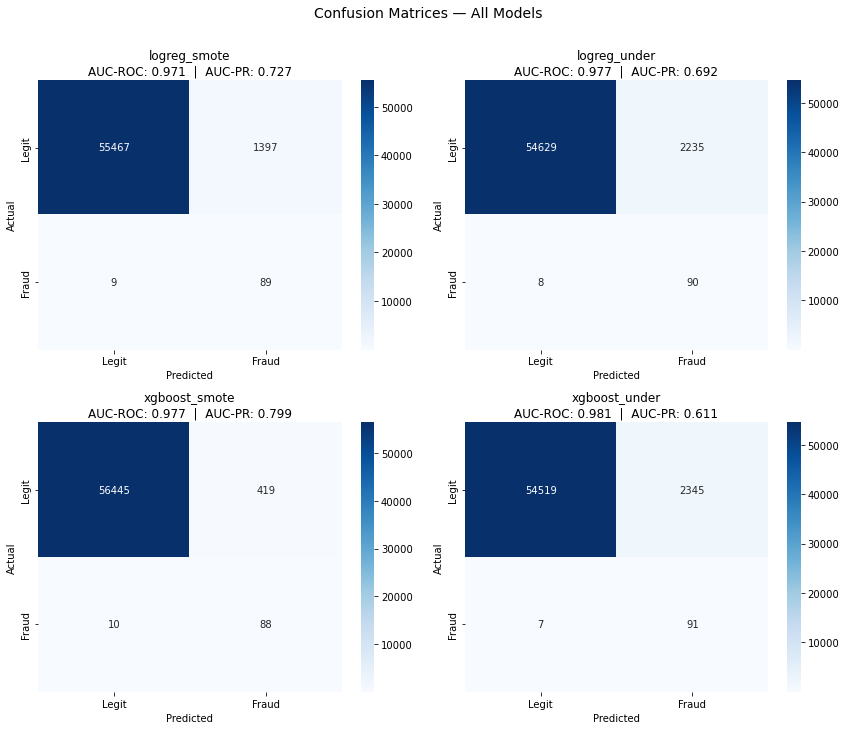

Saved → data/evaluation/confusion_matrices.png


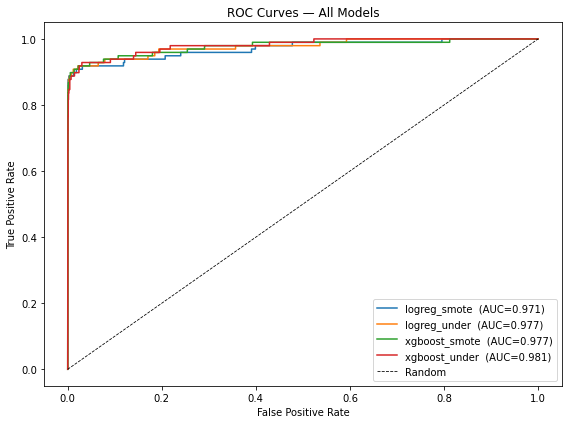

Saved → data/evaluation/roc_curves.png


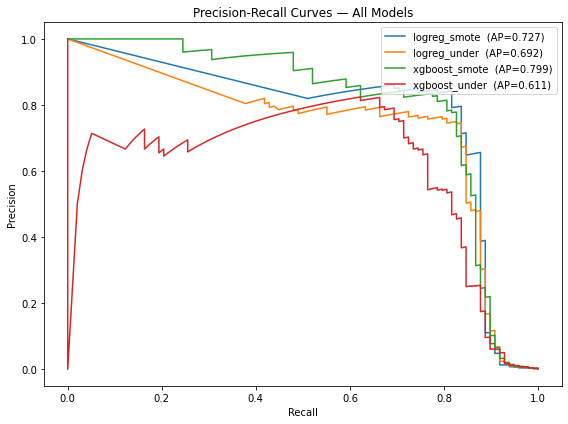

Saved → data/evaluation/pr_curves.png

MODEL                        AUC-ROC     AUC-PR
-------------------------------------------------------
logreg_smote                  0.9711     0.7270
logreg_under                  0.9771     0.6922
xgboost_smote                 0.9773     0.7987
xgboost_under                 0.9808     0.6107

✓ Best model by AUC-PR: xgboost_smote
  Saved → data/models/best_model.pkl  (used by Streamlit app)


In [3]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score
)
import os

os.makedirs('data/evaluation', exist_ok=True)

# ── Load test set ──────────────────────────────────────────────
X_test = joblib.load('data/features/X_test_eng.pkl')
y_test = joblib.load('data/preprocessed/y_test.pkl')

# ── Models to evaluate ─────────────────────────────────────────
model_keys = [
    'logreg_smote',
    'logreg_under',
    'xgboost_smote',
    'xgboost_under',
]

models = {k: joblib.load(f'data/models/{k}.pkl') for k in model_keys}

# ── Evaluation loop ────────────────────────────────────────────
summary = {}

for key, model in models.items():
    print(f"\n{'='*55}")
    print(f"Model: {key.upper()}")
    print(f"{'='*55}")

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Classification report
    print(classification_report(y_test, y_pred,
                                target_names=['Legit', 'Fraud']))

    auc_roc = roc_auc_score(y_test, y_proba)
    auc_pr  = average_precision_score(y_test, y_proba)
    print(f"AUC-ROC : {auc_roc:.4f}")
    print(f"AUC-PR  : {auc_pr:.4f}  ← most important for imbalanced data")

    summary[key] = {
        'auc_roc': auc_roc,
        'auc_pr' : auc_pr,
        'y_pred' : y_pred,
        'y_proba': y_proba,
    }

# ── Plot 1: Confusion matrices (2x2 grid) ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (key, vals) in enumerate(summary.items()):
    cm = confusion_matrix(y_test, vals['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'])
    axes[i].set_title(f"{key}\nAUC-ROC: {vals['auc_roc']:.3f}  |  AUC-PR: {vals['auc_pr']:.3f}")
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('data/evaluation/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → data/evaluation/confusion_matrices.png")

# ── Plot 2: ROC curves ─────────────────────────────────────────
plt.figure(figsize=(8, 6))
for key, vals in summary.items():
    fpr, tpr, _ = roc_curve(y_test, vals['y_proba'])
    plt.plot(fpr, tpr, label=f"{key}  (AUC={vals['auc_roc']:.3f})")

plt.plot([0,1],[0,1], 'k--', linewidth=0.8, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('data/evaluation/roc_curves.png', dpi=150)
plt.show()
print("Saved → data/evaluation/roc_curves.png")

# ── Plot 3: Precision-Recall curves ───────────────────────────
plt.figure(figsize=(8, 6))
for key, vals in summary.items():
    prec, rec, _ = precision_recall_curve(y_test, vals['y_proba'])
    plt.plot(rec, prec, label=f"{key}  (AP={vals['auc_pr']:.3f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — All Models')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('data/evaluation/pr_curves.png', dpi=150)
plt.show()
print("Saved → data/evaluation/pr_curves.png")

# ── Summary table ──────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"{'MODEL':<25} {'AUC-ROC':>10} {'AUC-PR':>10}")
print(f"{'-'*55}")
for key, vals in summary.items():
    print(f"{key:<25} {vals['auc_roc']:>10.4f} {vals['auc_pr']:>10.4f}")

best = max(summary, key=lambda k: summary[k]['auc_pr'])
print(f"\n✓ Best model by AUC-PR: {best}")
joblib.dump(models[best], 'data/models/best_model.pkl')
print(f"  Saved → data/models/best_model.pkl  (used by Streamlit app)")